# Shopping Behavior Prediction

**Predicting customer purchasing patterns using ensemble classification methods**

---

| Detail | Value |
|--------|-------|
| **Dataset** | Shopping Behavior Dataset |
| **Techniques** | Random Forest, LabelEncoder, StandardScaler, EDA, Feature Importance |
| **Author** | Ahmed Alnahrawy |



## 1. Setup & Data Loading

Import libraries and load the shopping behavior dataset.


In [29]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
df = pd.read_csv('../data/shopping_behavior_updated.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually



## 2. Exploratory Data Analysis

Explore customer demographics, purchase patterns, and categorical distributions.


In [31]:
df.shape

(3900, 18)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [33]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [34]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000



## 3. Feature Engineering & Preprocessing

Encode categorical variables and scale features.


In [37]:
df = df.drop('Customer ID',axis=1)
label_encoder = LabelEncoder()
df['Subscription_Status_Encoded'] = label_encoder.fit_transform(df['Subscription Status'])
num_cols = []
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        num_cols.append(col)

correlation_matrix = df[num_cols].corr()
print(correlation_matrix['Subscription_Status_Encoded'].sort_values(ascending=False))


Subscription_Status_Encoded    1.000000
Previous Purchases             0.030859
Age                            0.006492
Review Rating                 -0.006368
Purchase Amount (USD)         -0.006996
Name: Subscription_Status_Encoded, dtype: float64


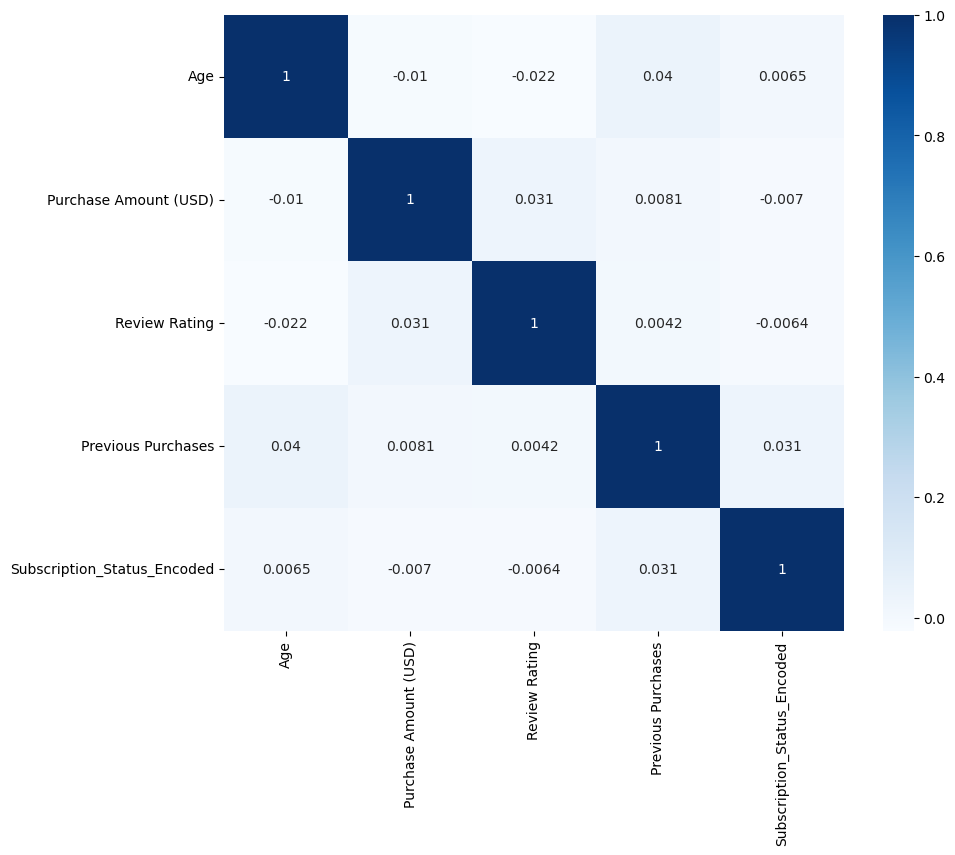

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues')
plt.show()

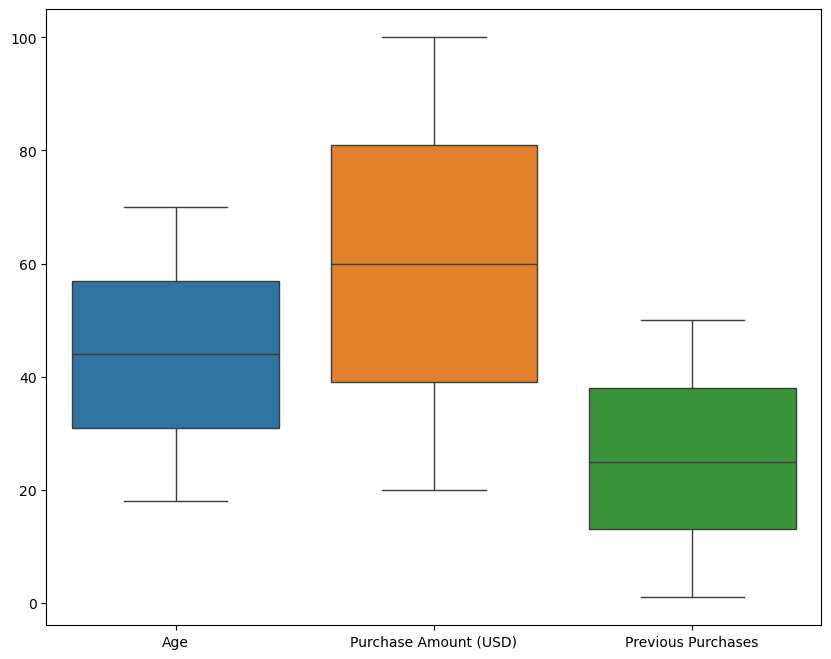

In [39]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df[['Age', 'Purchase Amount (USD)', 'Previous Purchases']])
plt.show()

In [40]:
bool_cols = [col for col in df.columns if df[col].nunique() == 2]

print(bool_cols)

['Gender', 'Subscription Status', 'Discount Applied', 'Promo Code Used', 'Subscription_Status_Encoded']


In [41]:
for col in bool_cols:
    df[col] = df[col].astype('category').cat.codes

In [42]:
df = pd.get_dummies(df, drop_first=True)

In [43]:
df.shape

(3900, 131)

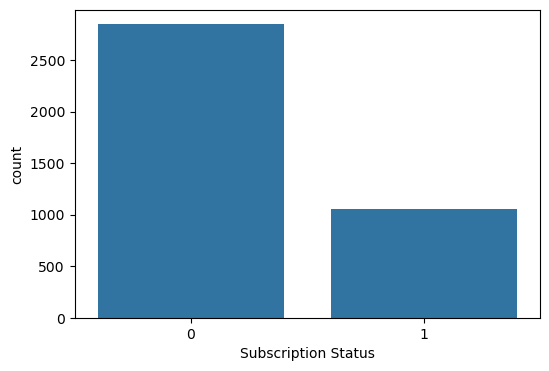

In [48]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Subscription Status', data=df)
plt.show()


## 4. Model Training & Evaluation

Train classification models and evaluate predictions.


In [49]:
from imblearn.over_sampling import SMOTE

X = df.drop(['Subscription Status', 'Subscription_Status_Encoded'], axis=1)
y = df['Subscription_Status_Encoded']


smote = SMOTE(sampling_strategy={1: 1500}, random_state=42)
X_res, y_res = smote.fit_resample(X, y)

df_resampled = pd.DataFrame(X_res, columns=X.columns)
df_resampled['Subscription Status'] = y_res.values


C:\Users\medoc\AppData\Local\Temp\ipykernel_11868\2246670627.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_resampled['Subscription Status'] = y_res.values


In [51]:
X_resampled = df_resampled.drop('Subscription Status', axis=1)
y_resampled = df_resampled['Subscription Status']

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train:\n{y_train.value_counts(normalize=True)}")
print(f"y_test:\n{y_test.value_counts(normalize=True)}")

X_train: (3042, 129)
X_test: (1305, 129)
y_train:
Subscription Status
0    0.654832
1    0.345168
Name: proportion, dtype: float64
y_test:
Subscription Status
0    0.655172
1    0.344828
Name: proportion, dtype: float64


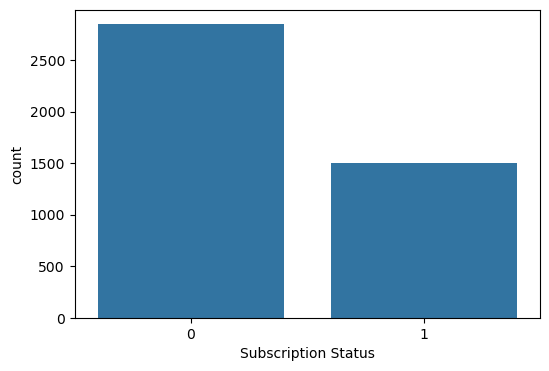

In [52]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Subscription Status', data=df_resampled)
plt.show()

In [53]:
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8467432950191571


In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[701 154]
 [ 46 404]]


In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.82      0.88       855
           1       0.72      0.90      0.80       450

    accuracy                           0.85      1305
   macro avg       0.83      0.86      0.84      1305
weighted avg       0.86      0.85      0.85      1305



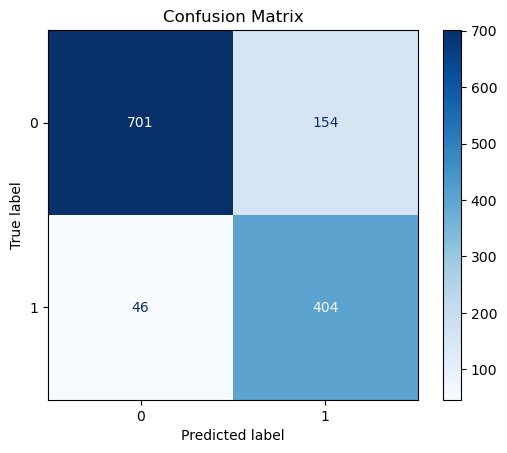

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


---

## Summary

This notebook demonstrated random forest, labelencoder, standardscaler, eda, feature importance techniques applied to the Shopping Behavior Dataset.

**Author:** Ahmed Alnahrawy | [GitHub](https://github.com/Ahmed-Na7rawy)
